In [1]:
# 1. 경로 설정 + 보조 캠페인 데이터 생성

from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_DIR = Path(r"C:\취준\mobile-game-retention-review-ua-analysis")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
SQL_DIR = PROJECT_DIR / "sql"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

for path in [RAW_DIR, PROCESSED_DIR, OUTPUT_TABLE_DIR, OUTPUT_FIGURE_DIR, DOCS_DIR, SQL_DIR, NOTEBOOK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

dates = pd.date_range("2026-01-01", periods=60, freq="D")

channels = ["Meta", "Google Ads", "TikTok", "Unity Ads", "AppLovin"]
countries = ["US", "KR", "JP", "BR", "IN"]
creative_types = ["video", "playable", "static"]

channel_params = {
    "Meta": {"spend": 900, "ctr": 0.018, "cvr": 0.145, "quality": 1.00, "revenue": 1.00},
    "Google Ads": {"spend": 950, "ctr": 0.016, "cvr": 0.150, "quality": 1.05, "revenue": 1.05},
    "TikTok": {"spend": 800, "ctr": 0.026, "cvr": 0.170, "quality": 0.82, "revenue": 0.80},
    "Unity Ads": {"spend": 700, "ctr": 0.015, "cvr": 0.135, "quality": 1.18, "revenue": 1.15},
    "AppLovin": {"spend": 750, "ctr": 0.017, "cvr": 0.140, "quality": 1.12, "revenue": 1.12},
}

country_params = {
    "US": {"cpc": 1.45, "quality": 1.10, "revenue": 1.45},
    "JP": {"cpc": 1.35, "quality": 1.06, "revenue": 1.35},
    "KR": {"cpc": 1.00, "quality": 1.04, "revenue": 1.00},
    "BR": {"cpc": 0.62, "quality": 0.88, "revenue": 0.62},
    "IN": {"cpc": 0.45, "quality": 0.82, "revenue": 0.45},
}

creative_params = {
    "playable": {"ctr": 1.20, "cvr": 1.16, "quality": 1.10},
    "video": {"ctr": 1.00, "cvr": 1.00, "quality": 1.00},
    "static": {"ctr": 0.82, "cvr": 0.88, "quality": 0.92},
}

# 5개 채널이 모두 포함되도록 채널당 8개 캠페인 생성
# 총 캠페인 수: 5 channels × 8 campaigns = 40 campaigns

campaign_rows = []
campaign_id = 1

for channel in channels:
    used_combinations = set()

    while len(used_combinations) < 8:
        country = rng.choice(countries)
        creative_type = rng.choice(creative_types)
        combo = (country, creative_type)

        # 같은 채널 안에서 국가×소재 조합이 너무 반복되지 않도록 제한
        if combo in used_combinations:
            continue

        used_combinations.add(combo)

        campaign_rows.append({
            "campaign_id": f"C{campaign_id:03d}",
            "channel": channel,
            "country": country,
            "creative_type": creative_type,
        })

        campaign_id += 1

campaign_master = pd.DataFrame(campaign_rows)

# 생성 결과 확인
print("Campaign count:", len(campaign_master))
print(campaign_master["channel"].value_counts())
display(campaign_master.head(20))

daily_rows = []

for _, c in campaign_master.iterrows():
    ch = c["channel"]
    co = c["country"]
    cr = c["creative_type"]

    for date in dates:
        weekday_factor = 1.10 if date.dayofweek in [4, 5, 6] else 1.00
        noise = rng.normal(1.0, 0.12)

        base_spend = channel_params[ch]["spend"] * weekday_factor * noise
        spend = max(80, base_spend * rng.uniform(0.75, 1.25))

        cpc = country_params[co]["cpc"] * rng.uniform(0.85, 1.15)
        clicks = max(1, int(spend / cpc))

        ctr = channel_params[ch]["ctr"] * creative_params[cr]["ctr"] * rng.uniform(0.85, 1.15)
        impressions = max(clicks, int(clicks / max(ctr, 0.001)))

        cvr = channel_params[ch]["cvr"] * creative_params[cr]["cvr"] * rng.uniform(0.85, 1.15)
        installs = max(1, int(clicks * cvr))

        quality = (
            channel_params[ch]["quality"]
            * country_params[co]["quality"]
            * creative_params[cr]["quality"]
            * rng.uniform(0.90, 1.10)
        )

        tutorial_completion_rate = np.clip(0.58 * quality + rng.normal(0, 0.035), 0.25, 0.90)
        d1_retention = np.clip(0.36 * quality + rng.normal(0, 0.030), 0.10, 0.70)
        d7_retention = np.clip(0.15 * quality + rng.normal(0, 0.020), 0.03, 0.40)

        revenue_factor = channel_params[ch]["revenue"] * country_params[co]["revenue"] * quality
        arpu_d1 = np.clip(0.08 * revenue_factor + rng.normal(0, 0.015), 0.005, 0.40)
        arpu_d7 = np.clip(0.34 * revenue_factor + rng.normal(0, 0.060), 0.02, 1.50)

        d1_revenue = installs * arpu_d1
        d7_revenue = installs * arpu_d7
        d7_roas = d7_revenue / spend

        daily_rows.append({
            "date": date,
            "campaign_id": c["campaign_id"],
            "channel": ch,
            "country": co,
            "creative_type": cr,
            "spend": round(spend, 2),
            "impressions": impressions,
            "clicks": clicks,
            "installs": installs,
            "tutorial_completion_rate": tutorial_completion_rate,
            "d1_retention": d1_retention,
            "d7_retention": d7_retention,
            "arpu_d1": arpu_d1,
            "arpu_d7": arpu_d7,
            "d1_revenue": d1_revenue,
            "d7_revenue": d7_revenue,
            "d7_roas": d7_roas,
        })

campaign_df = pd.DataFrame(daily_rows)

campaign_spend = campaign_df[
    ["date", "campaign_id", "channel", "country", "creative_type", "spend", "impressions", "clicks"]
].copy()

campaign_performance = campaign_df[
    [
        "date", "campaign_id", "channel", "country", "creative_type",
        "installs", "tutorial_completion_rate", "d1_retention", "d7_retention",
        "arpu_d1", "arpu_d7", "d1_revenue", "d7_revenue", "d7_roas"
    ]
].copy()

campaign_modeling_table = campaign_df.copy()
campaign_modeling_table["ctr"] = campaign_modeling_table["clicks"] / campaign_modeling_table["impressions"]
campaign_modeling_table["cvr"] = campaign_modeling_table["installs"] / campaign_modeling_table["clicks"]
campaign_modeling_table["cpi"] = campaign_modeling_table["spend"] / campaign_modeling_table["installs"]

campaign_spend.to_csv(RAW_DIR / "campaign_spend.csv", index=False, encoding="utf-8-sig")
campaign_performance.to_csv(RAW_DIR / "campaign_performance.csv", index=False, encoding="utf-8-sig")
campaign_modeling_table.to_csv(PROCESSED_DIR / "campaign_modeling_table.csv", index=False, encoding="utf-8-sig")

print("campaign_spend:", campaign_spend.shape)
print("campaign_performance:", campaign_performance.shape)
print("campaign_modeling_table:", campaign_modeling_table.shape)
display(campaign_modeling_table.head())

Campaign count: 40
channel
Meta          8
Google Ads    8
TikTok        8
Unity Ads     8
AppLovin      8
Name: count, dtype: int64


,campaign_id,channel,country,creative_type
0,C001,Meta,US,static
1,C002,Meta,BR,playable
2,C003,Meta,JP,static
3,C004,Meta,KR,video
4,C005,Meta,BR,static
5,C006,Meta,JP,video
6,C007,Meta,IN,playable
7,C008,Meta,JP,playable
8,C009,Google Ads,US,static
9,C010,Google Ads,BR,playable


campaign_spend: (2400, 8)
campaign_performance: (2400, 14)
campaign_modeling_table: (2400, 20)


,date,campaign_id,channel,country,creative_type,spend,impressions,clicks,installs,tutorial_completion_rate,d1_retention,d7_retention,arpu_d1,arpu_d7,d1_revenue,d7_revenue,d7_roas,ctr,cvr,cpi
0,2026-01-01,C001,Meta,US,static,733.57,30019,465,62,0.603452,0.365609,0.154820,0.146407,0.474978,9.077246,29.448647,0.040144,0.015490,0.133333,11.831774
1,2026-01-02,C001,Meta,US,static,1141.08,47406,728,94,0.621678,0.358172,0.144350,0.131652,0.493346,12.375262,46.374488,0.040641,0.015357,0.129121,12.139149
2,2026-01-03,C001,Meta,US,static,726.91,41835,577,69,0.591014,0.380874,0.169228,0.116553,0.542479,8.042181,37.431055,0.051493,0.013792,0.119584,10.534928
3,2026-01-04,C001,Meta,US,static,693.87,34615,545,68,0.547633,0.354061,0.150447,0.119420,0.459207,8.120559,31.226109,0.045003,0.015745,0.124771,10.203971
4,2026-01-05,C001,Meta,US,static,909.93,50563,654,73,0.655175,0.370811,0.158260,0.147725,0.523630,10.783928,38.224975,0.042009,0.012934,0.111621,12.464795


In [2]:
# 2. SQLite DB 생성 + SQL 파일 저장 + SQL 기반 KPI 산출

DB_PATH = PROCESSED_DIR / "mobile_game_campaign.db"

with sqlite3.connect(DB_PATH) as conn:
    campaign_spend.to_sql("campaign_spend", conn, if_exists="replace", index=False)
    campaign_performance.to_sql("campaign_performance", conn, if_exists="replace", index=False)
    campaign_modeling_table.to_sql("campaign_modeling_table", conn, if_exists="replace", index=False)

sql_queries = {
    "01_campaign_daily_kpi.sql": """
SELECT
    s.date,
    s.campaign_id,
    s.channel,
    s.country,
    s.creative_type,
    s.spend,
    s.impressions,
    s.clicks,
    p.installs,
    ROUND(CAST(s.clicks AS REAL) / NULLIF(s.impressions, 0), 4) AS ctr,
    ROUND(CAST(p.installs AS REAL) / NULLIF(s.clicks, 0), 4) AS cvr,
    ROUND(CAST(s.spend AS REAL) / NULLIF(p.installs, 0), 4) AS cpi,
    p.tutorial_completion_rate,
    p.d1_retention,
    p.d7_retention,
    p.d7_revenue,
    ROUND(CAST(p.d7_revenue AS REAL) / NULLIF(s.spend, 0), 4) AS d7_roas
FROM campaign_spend s
JOIN campaign_performance p
    ON s.date = p.date
   AND s.campaign_id = p.campaign_id;
""",
    "02_channel_cpi_cvr.sql": """
WITH channel_base AS (
    SELECT
        s.channel,
        SUM(s.spend) AS spend,
        SUM(s.impressions) AS impressions,
        SUM(s.clicks) AS clicks,
        SUM(p.installs) AS installs,
        SUM(p.d7_revenue) AS d7_revenue
    FROM campaign_spend s
    JOIN campaign_performance p
        ON s.date = p.date
       AND s.campaign_id = p.campaign_id
    GROUP BY s.channel
)
SELECT
    channel,
    spend,
    impressions,
    clicks,
    installs,
    ROUND(CAST(clicks AS REAL) / NULLIF(impressions, 0), 4) AS ctr,
    ROUND(CAST(installs AS REAL) / NULLIF(clicks, 0), 4) AS cvr,
    ROUND(CAST(spend AS REAL) / NULLIF(installs, 0), 4) AS cpi,
    ROUND(CAST(d7_revenue AS REAL) / NULLIF(spend, 0), 4) AS d7_roas
FROM channel_base
ORDER BY d7_roas DESC;
""",
    "03_campaign_roas_d7.sql": """
SELECT
    campaign_id,
    channel,
    country,
    creative_type,
    SUM(spend) AS spend,
    SUM(installs) AS installs,
    ROUND(SUM(spend) / NULLIF(SUM(installs), 0), 4) AS cpi,
    ROUND(AVG(d1_retention), 4) AS avg_d1_retention,
    ROUND(AVG(d7_retention), 4) AS avg_d7_retention,
    SUM(d7_revenue) AS d7_revenue,
    ROUND(SUM(d7_revenue) / NULLIF(SUM(spend), 0), 4) AS d7_roas
FROM campaign_modeling_table
GROUP BY campaign_id, channel, country, creative_type
ORDER BY d7_roas DESC;
""",
    "04_campaign_score_base_table.sql": """
SELECT
    campaign_id,
    channel,
    country,
    creative_type,
    SUM(spend) AS spend,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(installs) AS installs,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(installs) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(spend) * 1.0 / NULLIF(SUM(installs), 0), 4) AS cpi,
    ROUND(AVG(tutorial_completion_rate), 4) AS tutorial_completion_rate,
    ROUND(AVG(d1_retention), 4) AS d1_retention,
    ROUND(AVG(d7_retention), 4) AS d7_retention,
    ROUND(SUM(d7_revenue) * 1.0 / NULLIF(SUM(spend), 0), 4) AS d7_roas
FROM campaign_modeling_table
GROUP BY campaign_id, channel, country, creative_type;
""",
    "05_modeling_base_table.sql": """
SELECT
    date,
    campaign_id,
    channel,
    country,
    creative_type,
    spend,
    impressions,
    clicks,
    installs,
    ctr,
    cvr,
    cpi,
    tutorial_completion_rate,
    d1_retention,
    arpu_d1,
    d1_revenue,
    d7_roas
FROM campaign_modeling_table;
"""
}

for filename, query in sql_queries.items():
    (SQL_DIR / filename).write_text(query.strip(), encoding="utf-8")

with sqlite3.connect(DB_PATH) as conn:
    sql_outputs = {}
    for filename, query in sql_queries.items():
        output_name = filename.replace(".sql", ".csv")
        result_df = pd.read_sql_query(query, conn)
        result_df.to_csv(OUTPUT_TABLE_DIR / output_name, index=False, encoding="utf-8-sig")
        sql_outputs[filename] = result_df
        print(filename, result_df.shape)

display(sql_outputs["02_channel_cpi_cvr.sql"])
display(sql_outputs["03_campaign_roas_d7.sql"].head())

01_campaign_daily_kpi.sql (2400, 17)
02_channel_cpi_cvr.sql (5, 9)
03_campaign_roas_d7.sql (40, 11)
04_campaign_score_base_table.sql (40, 15)
05_modeling_base_table.sql (2400, 17)


,channel,spend,impressions,clicks,installs,ctr,cvr,cpi,d7_roas
0,Unity Ads,354542.28,27492116,426603,60759,0.0155,0.1424,5.8352,0.0647
1,Google Ads,469153.67,36868349,572994,86236,0.0155,0.1505,5.4403,0.0576
2,AppLovin,378460.20,32111196,517775,71323,0.0161,0.1377,5.3063,0.0544
3,Meta,443652.24,28549933,519227,78141,0.0182,0.1505,5.6776,0.0492
4,TikTok,404748.29,21405211,521952,85957,0.0244,0.1647,4.7087,0.0354


,campaign_id,channel,country,creative_type,spend,installs,cpi,avg_d1_retention,avg_d7_retention,d7_revenue,d7_roas
0,C028,Unity Ads,US,playable,45535.04,4749,9.5883,0.5116,0.2158,3788.252475,0.0832
1,C014,Google Ads,US,playable,58055.66,6884,8.4334,0.4575,0.1903,4592.429067,0.0791
2,C012,Google Ads,JP,playable,58382.96,7633,7.6488,0.4329,0.1850,4473.458779,0.0766
3,C030,Unity Ads,BR,playable,41757.85,10687,3.9074,0.4080,0.1713,2977.875414,0.0713
4,C026,Unity Ads,JP,video,43620.49,4375,9.9704,0.4551,0.1871,2958.406676,0.0678


,campaign_id,channel,country,creative_type,spend,impressions,clicks,installs,ctr,cvr,...,d1_retention,d7_retention,d7_roas,cpi_score,cvr_score,d7_retention_score,d7_roas_score,tutorial_score,campaign_performance_score,budget_action
11,C012,Google Ads,JP,playable,58382.96,2230846,43367,7633,0.0194,0.1760,...,0.4329,0.1850,0.0766,0.475,0.9500,0.9000,0.9500,0.875,81.5000,Scale
13,C014,Google Ads,US,playable,58055.66,2045521,39796,6884,0.0195,0.1730,...,0.4575,0.1903,0.0791,0.375,0.8875,0.9750,0.9750,0.975,80.7500,Scale
29,C030,Unity Ads,BR,playable,41757.85,3815608,68052,10687,0.0178,0.1570,...,0.4080,0.1713,0.0713,0.700,0.7250,0.8000,0.9250,0.775,79.0000,Scale
27,C028,Unity Ads,US,playable,45535.04,1735244,31014,4749,0.0179,0.1531,...,0.5116,0.2158,0.0832,0.250,0.6750,1.0000,1.0000,1.000,74.7500,Maintain
26,C027,Unity Ads,IN,playable,45452.26,5551909,99317,15510,0.0179,0.1562,...,0.3816,0.1601,0.0632,0.925,0.7000,0.6250,0.7500,0.600,74.5000,Maintain
9,C010,Google Ads,BR,playable,60071.80,5107305,97071,17034,0.0190,0.1755,...,0.3595,0.1556,0.0645,0.775,0.9250,0.5625,0.7875,0.450,73.8750,Maintain
7,C008,Meta,JP,playable,55584.47,1984176,42540,7076,0.0214,0.1663,...,0.4150,0.1721,0.0650,0.450,0.7875,0.8500,0.8250,0.850,73.1250,Maintain
32,C033,AppLovin,IN,playable,48129.05,5292713,108211,17363,0.0204,0.1605,...,0.3621,0.1504,0.0645,0.950,0.7500,0.4250,0.7875,0.475,71.4375,Maintain
30,C031,Unity Ads,KR,video,45653.14,2974042,45405,6180,0.0153,0.1361,...,0.4437,0.1895,0.0667,0.500,0.3500,0.9500,0.8500,0.925,69.1250,Maintain
6,C007,Meta,IN,playable,55533.58,5761945,123754,20676,0.0215,0.1671,...,0.3176,0.1377,0.0519,0.975,0.8500,0.3250,0.5125,0.275,63.6875,Maintain


,budget_action,count
0,Review,15
1,Maintain,12
2,Reduce,10
3,Scale,3


,budget_action,campaign_count,avg_score,avg_cpi,avg_d7_retention,avg_d7_roas,total_spend,total_installs
3,Scale,3,80.416667,6.663200,0.182200,0.075667,158196.47,25204
0,Maintain,12,66.494792,6.154058,0.168033,0.063658,602762.77,129098
2,Review,15,46.079167,7.190267,0.148633,0.048753,754525.61,133572
1,Reduce,10,29.462500,7.148010,0.124560,0.036930,535071.83,94542


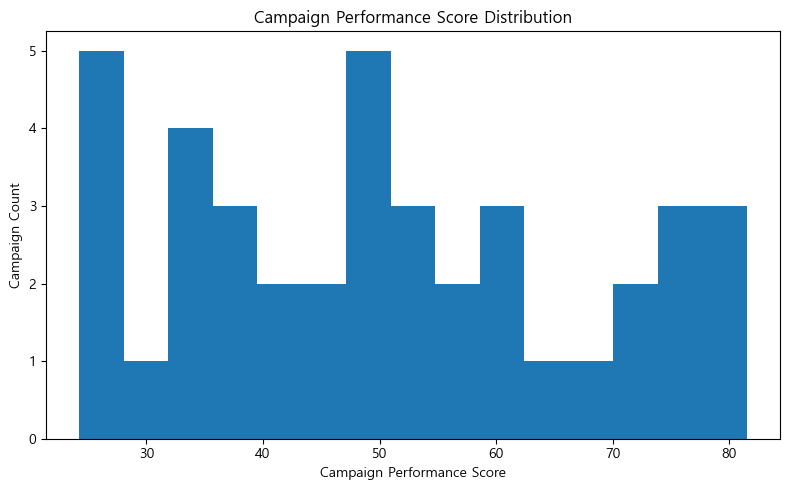

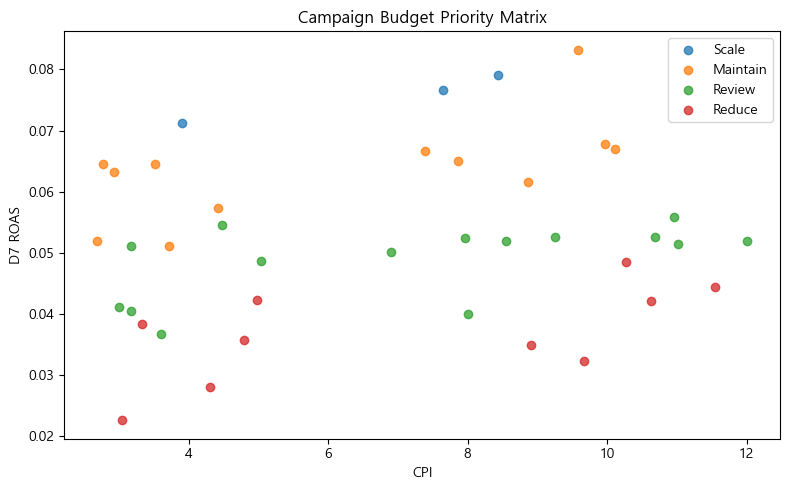

In [3]:
# 3. Campaign Performance Score 산출 + 예산 액션 후보 분류

score_base = sql_outputs["04_campaign_score_base_table.sql"].copy()

score_base["cpi_score"] = 1 - score_base["cpi"].rank(pct=True)
score_base["cvr_score"] = score_base["cvr"].rank(pct=True)
score_base["d7_retention_score"] = score_base["d7_retention"].rank(pct=True)
score_base["d7_roas_score"] = score_base["d7_roas"].rank(pct=True)
score_base["tutorial_score"] = score_base["tutorial_completion_rate"].rank(pct=True)

score_base["campaign_performance_score"] = (
    0.25 * score_base["cpi_score"]
    + 0.20 * score_base["cvr_score"]
    + 0.25 * score_base["d7_retention_score"]
    + 0.25 * score_base["d7_roas_score"]
    + 0.05 * score_base["tutorial_score"]
) * 100

def classify_budget_action(score):
    if score >= 75:
        return "Scale"
    if score >= 55:
        return "Maintain"
    if score >= 35:
        return "Review"
    return "Reduce"

score_base["budget_action"] = score_base["campaign_performance_score"].apply(classify_budget_action)

campaign_score = score_base.sort_values("campaign_performance_score", ascending=False)

campaign_score.to_csv(
    OUTPUT_TABLE_DIR / "campaign_performance_score.csv",
    index=False,
    encoding="utf-8-sig"
)

display(campaign_score.head(10))
display(campaign_score["budget_action"].value_counts().reset_index())

action_summary = (
    campaign_score.groupby("budget_action")
    .agg(
        campaign_count=("campaign_id", "count"),
        avg_score=("campaign_performance_score", "mean"),
        avg_cpi=("cpi", "mean"),
        avg_d7_retention=("d7_retention", "mean"),
        avg_d7_roas=("d7_roas", "mean"),
        total_spend=("spend", "sum"),
        total_installs=("installs", "sum"),
    )
    .reset_index()
    .sort_values("avg_score", ascending=False)
)

action_summary.to_csv(
    OUTPUT_TABLE_DIR / "campaign_budget_action_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

display(action_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(campaign_score["campaign_performance_score"], bins=15)
ax.set_title("Campaign Performance Score Distribution")
ax.set_xlabel("Campaign Performance Score")
ax.set_ylabel("Campaign Count")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "campaign_score_distribution.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for action in ["Scale", "Maintain", "Review", "Reduce"]:
    subset = campaign_score[campaign_score["budget_action"] == action]
    ax.scatter(subset["cpi"], subset["d7_roas"], label=action, alpha=0.75)

ax.set_title("Campaign Budget Priority Matrix")
ax.set_xlabel("CPI")
ax.set_ylabel("D7 ROAS")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "campaign_budget_priority_matrix.png", dpi=150)
plt.show()

,model,mae,rmse,r2
0,Linear Regression,0.009727,0.013542,0.538336
1,Random Forest,0.010233,0.014021,0.505077


,channel,rows,actual_d7_roas,predicted_d7_roas,mean_error,mean_abs_error
0,AppLovin,116,0.054678,0.055066,-0.000387,0.010764
1,Google Ads,120,0.059128,0.056330,0.002798,0.010191
3,TikTok,119,0.034845,0.035217,-0.000373,0.009740
2,Meta,130,0.049797,0.049834,-0.000037,0.009732
4,Unity Ads,115,0.062611,0.063904,-0.001293,0.008179


,country,rows,actual_d7_roas,predicted_d7_roas,mean_error,mean_abs_error
1,IN,105,0.046565,0.046871,-0.000306,0.017849
0,BR,157,0.048986,0.048158,0.000829,0.012679
3,KR,73,0.054068,0.052880,0.001188,0.007585
2,JP,163,0.053820,0.053596,0.000224,0.005434
4,US,102,0.058417,0.059676,-0.001259,0.005217


,creative_type,rows,actual_d7_roas,predicted_d7_roas,mean_error,mean_abs_error
0,playable,173,0.063122,0.063454,-0.000332,0.011861
2,video,182,0.054132,0.053619,0.000512,0.009928
1,static,245,0.042801,0.042568,0.000233,0.008072


,date,campaign_id,channel,country,creative_type,actual_d7_roas,predicted_d7_roas,prediction_error,absolute_error
202,2026-01-28,C016,Google Ads,IN,static,0.096552,0.038518,0.058034,0.058034
528,2026-02-01,C016,Google Ads,IN,static,0.091733,0.034647,0.057086,0.057086
345,2026-01-19,C033,AppLovin,IN,playable,0.120612,0.065013,0.055599,0.055599
445,2026-02-16,C033,AppLovin,IN,playable,0.009604,0.058659,-0.049054,0.049054
88,2026-02-10,C002,Meta,BR,playable,0.018169,0.067178,-0.049009,0.049009


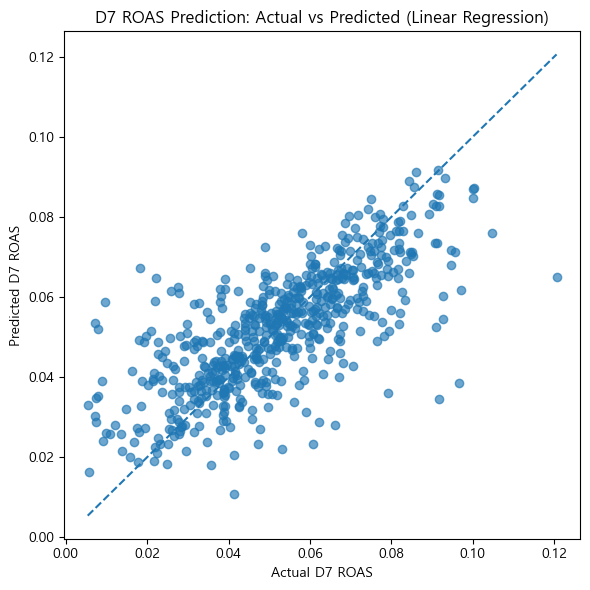

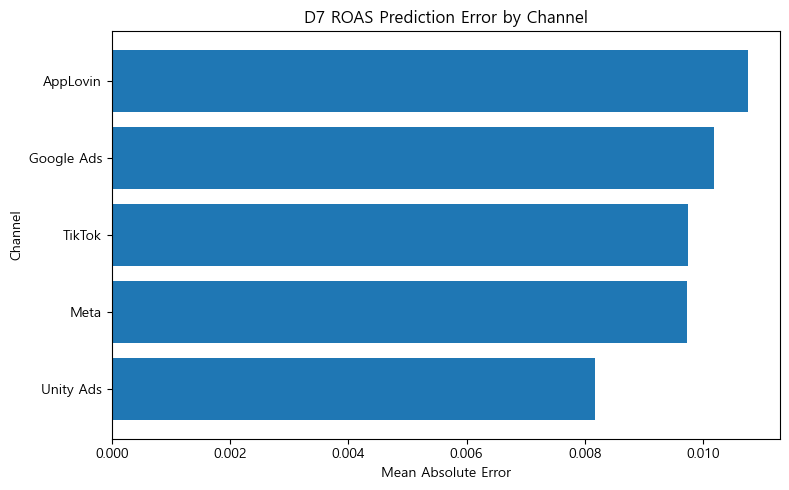

In [4]:
# 4. D7 ROAS 예측 모델 구축 + 예측 오차 분석

model_df = campaign_modeling_table.copy()

feature_cols_num = [
    "spend",
    "impressions",
    "clicks",
    "installs",
    "ctr",
    "cvr",
    "cpi",
    "tutorial_completion_rate",
    "d1_retention",
    "arpu_d1",
    "d1_revenue",
]

feature_cols_cat = [
    "channel",
    "country",
    "creative_type",
]

target_col = "d7_roas"

model_df = model_df.dropna(subset=feature_cols_num + feature_cols_cat + [target_col]).copy()

X = model_df[feature_cols_num + feature_cols_cat]
y = model_df[target_col]

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    model_df.index,
    test_size=0.25,
    random_state=RANDOM_SEED
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=RANDOM_SEED
        ))
    ])
}

model_result_rows = []
prediction_frames = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_result_rows.append({
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    })

    pred_df = model_df.loc[test_idx].copy()
    pred_df["model"] = model_name
    pred_df["actual_d7_roas"] = y_test.values
    pred_df["predicted_d7_roas"] = pred
    pred_df["prediction_error"] = pred_df["actual_d7_roas"] - pred_df["predicted_d7_roas"]
    pred_df["absolute_error"] = pred_df["prediction_error"].abs()
    prediction_frames.append(pred_df)

model_results = pd.DataFrame(model_result_rows).sort_values("mae")
all_predictions = pd.concat(prediction_frames, ignore_index=True)

model_results.to_csv(
    OUTPUT_TABLE_DIR / "d7_roas_model_results.csv",
    index=False,
    encoding="utf-8-sig"
)

all_predictions.to_csv(
    OUTPUT_TABLE_DIR / "d7_roas_predictions_all_models.csv",
    index=False,
    encoding="utf-8-sig"
)

display(model_results)

best_model_name = model_results.iloc[0]["model"]
best_predictions = all_predictions[all_predictions["model"] == best_model_name].copy()

best_predictions.to_csv(
    OUTPUT_TABLE_DIR / "d7_roas_prediction_error_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

error_by_channel = (
    best_predictions.groupby("channel")
    .agg(
        rows=("campaign_id", "count"),
        actual_d7_roas=("actual_d7_roas", "mean"),
        predicted_d7_roas=("predicted_d7_roas", "mean"),
        mean_error=("prediction_error", "mean"),
        mean_abs_error=("absolute_error", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_error", ascending=False)
)

error_by_country = (
    best_predictions.groupby("country")
    .agg(
        rows=("campaign_id", "count"),
        actual_d7_roas=("actual_d7_roas", "mean"),
        predicted_d7_roas=("predicted_d7_roas", "mean"),
        mean_error=("prediction_error", "mean"),
        mean_abs_error=("absolute_error", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_error", ascending=False)
)

error_by_creative = (
    best_predictions.groupby("creative_type")
    .agg(
        rows=("campaign_id", "count"),
        actual_d7_roas=("actual_d7_roas", "mean"),
        predicted_d7_roas=("predicted_d7_roas", "mean"),
        mean_error=("prediction_error", "mean"),
        mean_abs_error=("absolute_error", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_error", ascending=False)
)

high_error_cases = best_predictions.sort_values("absolute_error", ascending=False).head(20)

error_by_channel.to_csv(OUTPUT_TABLE_DIR / "d7_roas_error_by_channel.csv", index=False, encoding="utf-8-sig")
error_by_country.to_csv(OUTPUT_TABLE_DIR / "d7_roas_error_by_country.csv", index=False, encoding="utf-8-sig")
error_by_creative.to_csv(OUTPUT_TABLE_DIR / "d7_roas_error_by_creative.csv", index=False, encoding="utf-8-sig")
high_error_cases.to_csv(OUTPUT_TABLE_DIR / "d7_roas_high_error_cases.csv", index=False, encoding="utf-8-sig")

display(error_by_channel)
display(error_by_country)
display(error_by_creative)
display(high_error_cases[["date", "campaign_id", "channel", "country", "creative_type", "actual_d7_roas", "predicted_d7_roas", "prediction_error", "absolute_error"]].head())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(best_predictions["actual_d7_roas"], best_predictions["predicted_d7_roas"], alpha=0.65)
min_val = min(best_predictions["actual_d7_roas"].min(), best_predictions["predicted_d7_roas"].min())
max_val = max(best_predictions["actual_d7_roas"].max(), best_predictions["predicted_d7_roas"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title(f"D7 ROAS Prediction: Actual vs Predicted ({best_model_name})")
ax.set_xlabel("Actual D7 ROAS")
ax.set_ylabel("Predicted D7 ROAS")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "d7_roas_actual_vs_predicted.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_error = error_by_channel.sort_values("mean_abs_error", ascending=True)
ax.barh(plot_error["channel"], plot_error["mean_abs_error"])
ax.set_title("D7 ROAS Prediction Error by Channel")
ax.set_xlabel("Mean Absolute Error")
ax.set_ylabel("Channel")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "d7_roas_error_by_channel.png", dpi=150)
plt.show()

In [5]:
# 5. 최종 문서 저장 + 생성 파일 확인

campaign_score_doc = f"""
# Campaign Performance Score Logic

## 목적
보조 캠페인 데이터에서 CPI, CVR, D7 Retention, D7 ROAS, Tutorial Completion Rate를 함께 고려해 캠페인별 예산 운영 우선순위를 산출했다.

## 점수 구성
- CPI Score: CPI가 낮을수록 높은 점수
- CVR Score: 클릭 대비 설치 전환율
- D7 Retention Score: 설치 후 7일 잔존율
- D7 ROAS Score: 광고비 대비 7일 수익성
- Tutorial Completion Score: 초기 온보딩 완료율

## 산식
Campaign Performance Score =
0.25 × CPI Score
+ 0.20 × CVR Score
+ 0.25 × D7 Retention Score
+ 0.25 × D7 ROAS Score
+ 0.05 × Tutorial Completion Score

## 해석
이 점수는 실제 광고 네트워크 최적화 알고리즘이 아니라, 캠페인 성과를 비교하기 위한 규칙 기반 스코어다.
다만 여러 초기 성과 지표를 표준화하고 가중합으로 결합하는 과정은 향후 D7 ROAS 또는 LTV 예측 모델의 Feature Engineering으로 확장 가능하다.

## 예산 액션 기준
- Scale: 75점 이상
- Maintain: 55점 이상 75점 미만
- Review: 35점 이상 55점 미만
- Reduce: 35점 미만
"""

prediction_doc = f"""
# D7 ROAS Prediction Error Analysis

## 분석 목적
초기 캠페인 성과 지표를 활용해 D7 ROAS를 예측하고, 실제값과 예측값의 오차가 큰 세그먼트를 확인했다.

## 사용 피처
- channel
- country
- creative_type
- spend
- impressions
- clicks
- installs
- ctr
- cvr
- cpi
- tutorial_completion_rate
- d1_retention
- arpu_d1
- d1_revenue

## 제외한 피처
- d7_retention
- d7_revenue
- d7_roas

위 변수들은 D7 이후 확인 가능한 사후 정보 또는 타겟과 직접 연결되는 정보이므로 모델 피처에서 제외했다.

## 모델 결과
{model_results.to_markdown(index=False)}

## 해석 원칙
모델 성능 자체를 과장하지 않고, 예측 오차가 큰 채널·국가·소재 유형을 확인하는 데 초점을 두었다.
이 분석은 슈퍼센트 공고에서 요구하는 ML 예측 모델의 오차 원인 분석과 Feature Engineering 사고를 보여주기 위한 보조 분석이다.

## 주의
이 파트는 실제 기업 내부 광고 데이터가 아니라, 모바일 게임 UA 성과 분석 구조를 재현하기 위해 구성한 보조 캠페인 데이터 기반 분석이다.
실제 A/B 테스트 분석 및 Google Play 리뷰 분석 파트와는 데이터 레벨에서 결합하지 않는다.
"""

campaign_analysis_doc = f"""
# 보조 캠페인 데이터 기반 UA KPI·ROAS·ML 분석 요약

## 데이터 성격
이 파트는 실제 기업 광고 데이터가 아니라, 모바일 게임 UA 성과 분석 구조를 재현하기 위해 구성한 보조 캠페인 데이터다.
실제 데이터 기반 분석 파트인 Cookie Cats A/B 테스트 분석, Google Play 리뷰 신호 분석과 구분해 해석한다.

## 데이터 규모
- 분석 기간: 60일
- 캠페인 수: 40개
- 일자 × 캠페인 행 수: {len(campaign_modeling_table):,}행
- 채널: Meta, Google Ads, TikTok, Unity Ads, AppLovin
- 국가: US, KR, JP, BR, IN
- 소재 유형: video, playable, static

## 수행 분석
1. SQL 기반 CTR, CVR, CPI, D7 ROAS 산출
2. Campaign Performance Score 산출
3. 예산 확대·유지·점검·축소 후보 분류
4. 초기 KPI 기반 D7 ROAS 예측 모델 구축
5. 예측 오차를 채널·국가·소재 유형별로 분석

## 핵심 포트폴리오 메시지
캠페인 성과는 CPI만으로 판단하기 어렵다.
유저 획득 비용이 낮더라도 D7 Retention과 D7 ROAS가 낮다면 예산 확대 후보로 보기 어렵다.
반대로 CPI가 높더라도 잔존율과 ROAS가 높다면 고품질 유저 확보 채널로 볼 수 있다.
"""

(DOCS_DIR / "campaign_score_logic.md").write_text(campaign_score_doc, encoding="utf-8")
(DOCS_DIR / "prediction_error_analysis.md").write_text(prediction_doc, encoding="utf-8")
(DOCS_DIR / "campaign_support_data_analysis.md").write_text(campaign_analysis_doc, encoding="utf-8")

created_files = [
    RAW_DIR / "campaign_spend.csv",
    RAW_DIR / "campaign_performance.csv",
    PROCESSED_DIR / "campaign_modeling_table.csv",
    PROCESSED_DIR / "mobile_game_campaign.db",
    OUTPUT_TABLE_DIR / "01_campaign_daily_kpi.csv",
    OUTPUT_TABLE_DIR / "02_channel_cpi_cvr.csv",
    OUTPUT_TABLE_DIR / "03_campaign_roas_d7.csv",
    OUTPUT_TABLE_DIR / "04_campaign_score_base_table.csv",
    OUTPUT_TABLE_DIR / "05_modeling_base_table.csv",
    OUTPUT_TABLE_DIR / "campaign_performance_score.csv",
    OUTPUT_TABLE_DIR / "campaign_budget_action_summary.csv",
    OUTPUT_TABLE_DIR / "d7_roas_model_results.csv",
    OUTPUT_TABLE_DIR / "d7_roas_prediction_error_detail.csv",
    OUTPUT_TABLE_DIR / "d7_roas_error_by_channel.csv",
    OUTPUT_TABLE_DIR / "d7_roas_error_by_country.csv",
    OUTPUT_TABLE_DIR / "d7_roas_error_by_creative.csv",
    OUTPUT_TABLE_DIR / "d7_roas_high_error_cases.csv",
    OUTPUT_FIGURE_DIR / "campaign_score_distribution.png",
    OUTPUT_FIGURE_DIR / "campaign_budget_priority_matrix.png",
    OUTPUT_FIGURE_DIR / "d7_roas_actual_vs_predicted.png",
    OUTPUT_FIGURE_DIR / "d7_roas_error_by_channel.png",
    DOCS_DIR / "campaign_score_logic.md",
    DOCS_DIR / "prediction_error_analysis.md",
    DOCS_DIR / "campaign_support_data_analysis.md",
]

for file_path in created_files:
    print(file_path.name, "exists:", file_path.exists())

print("\nDone.")

campaign_spend.csv exists: True
campaign_performance.csv exists: True
campaign_modeling_table.csv exists: True
mobile_game_campaign.db exists: True
01_campaign_daily_kpi.csv exists: True
02_channel_cpi_cvr.csv exists: True
03_campaign_roas_d7.csv exists: True
04_campaign_score_base_table.csv exists: True
05_modeling_base_table.csv exists: True
campaign_performance_score.csv exists: True
campaign_budget_action_summary.csv exists: True
d7_roas_model_results.csv exists: True
d7_roas_prediction_error_detail.csv exists: True
d7_roas_error_by_channel.csv exists: True
d7_roas_error_by_country.csv exists: True
d7_roas_error_by_creative.csv exists: True
d7_roas_high_error_cases.csv exists: True
campaign_score_distribution.png exists: True
campaign_budget_priority_matrix.png exists: True
d7_roas_actual_vs_predicted.png exists: True
d7_roas_error_by_channel.png exists: True
campaign_score_logic.md exists: True
prediction_error_analysis.md exists: True
campaign_support_data_analysis.md exists: Tru